## Notebook 07 - Fragility vs league points
Núria Pascual Salas

**Content:**
Tests whether team structural fragility is related to league performance. Includes the four robustness measures used in the thesis: PageRank attack, betweenness attack, LCC, and diameter. It also checks whether playing style (SF) is independent of fragility, using SF as a continuous variable.

**Inputs:**
- fragility_per_team.csv (from notebook 05)
- fragility_per_team_betweenness.csv (from notebook 05b)
- robustness_diameter_LCC_per_team.csv (from notebook 05c)
- player_match_matrix.csv (team-level SF, from notebook 06)

**Outputs:**
- outputs/csv/fragility_vs_points.csv
- outputs/figures/fragility_vs_points_pagerank.png
- outputs/figures/fragility_vs_points_betweenness.png
- outputs/figures/sf_vs_fragility_pagerank.png

**Used in:** Chapter 4 (fragility vs performance) and Chapter 5.

In [5]:
from utils import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr, spearmanr

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

### 1. Compute total league points per team

In [6]:
team_total_points = {team_name: 0 for team_name in all_teams.values()}
team_n_matches    = {team_name: 0 for team_name in all_teams.values()}

for m_id, events in stream_matches_from_zip(zip_path, folder_laliga, "_events.json"):
    teams_in_match = list({(e['team']['id'], e['team']['name'])
                           for e in events if 'team' in e})

    for team_id, team_name in teams_in_match:
        if team_name not in team_total_points:
            continue
        _, _, _, points = get_match_result(events, team_id)
        team_total_points[team_name] += points
        team_n_matches[team_name]    += 1

df_points = pd.DataFrame([
    {'team': name, 'total_points': pts, 'n_matches': team_n_matches[name]}
    for name, pts in team_total_points.items()
]).sort_values('total_points', ascending=False).reset_index(drop=True)

print("Final league standings (LaLiga 2023-24):")
print(df_points.to_string(index=False))

Final league standings (LaLiga 2023-24):
            team  total_points  n_matches
     Real Madrid            97         38
       Barcelona            82         38
          Girona            81         38
 Atlético Madrid            74         38
   Athletic Club            72         38
      Real Betis            60         38
   Real Sociedad            58         38
      Villarreal            51         38
        Valencia            49         38
         Osasuna            45         38
Deportivo Alavés            45         38
          Getafe            43         38
        Mallorca            42         38
      Celta Vigo            42         38
      Las Palmas            42         38
         Sevilla            42         38
  Rayo Vallecano            40         38
           Cádiz            32         38
         Almería            21         38
         Granada            19         38


### 2. Load fragility values and compute team-level SF

In [7]:
# Fragility (PageRank attack) and (Betweenness attack)
df_frag_pr = pd.read_csv(f'{CSV_DIR}/fragility_per_team.csv')
df_frag_pr = df_frag_pr.rename(columns={'fragility': 'fragility_pagerank'})

df_frag_bt = pd.read_csv(f'{CSV_DIR}/fragility_per_team_betweenness.csv')
df_frag_bt = df_frag_bt.rename(columns={'fragility': 'fragility_betweenness'})

# Fragility (diameter and LCC) from notebook 05c
df_frag_dS = pd.read_csv(f'{CSV_DIR}/robustness_diameter_LCC_per_team.csv')

# Team-level SF: mean across all matches
df_pmm = pd.read_csv(f'{CSV_DIR}/player_match_matrix.csv', encoding='utf-8-sig')
df_team_sf = (df_pmm.groupby(['match_id', 'team_name'])['team_sf']
                     .first()
                     .reset_index()
                     .groupby('team_name')['team_sf']
                     .mean()
                     .reset_index()
                     .rename(columns={'team_name': 'team', 'team_sf': 'sf_mean'}))

# Merge everything
df = (df_points
      .merge(df_frag_pr[['team', 'fragility_pagerank']],          on='team')
      .merge(df_frag_bt[['team', 'fragility_betweenness']],       on='team')
      .merge(df_frag_dS[['team', 'fragility_diameter', 'fragility_LCC']], on='team')
      .merge(df_team_sf,                                          on='team'))

df.to_csv(f'{CSV_DIR}/fragility_vs_points.csv', index=False)
print(df.round(3).to_string(index=False))

            team  total_points  n_matches  fragility_pagerank  fragility_betweenness  fragility_diameter  fragility_LCC  sf_mean
     Real Madrid            97         38               0.300                  0.348               0.056          0.029    0.111
       Barcelona            82         38               0.250                  0.283              -0.749          0.011    0.122
          Girona            81         38               0.326                  0.345              -0.216          0.036    0.139
 Atlético Madrid            74         38               0.332                  0.344              -0.426          0.045    0.155
   Athletic Club            72         38               0.234                  0.250              -0.124          0.016    0.198
      Real Betis            60         38               0.330                  0.349              -0.027          0.032    0.179
   Real Sociedad            58         38               0.340                  0.360             

### 3. Correlation: PageRank fragility vs Points

In [8]:
r_pearson_pr,  p_pearson_pr  = pearsonr(df['fragility_pagerank'], df['total_points'])
r_spearman_pr, p_spearman_pr = spearmanr(df['fragility_pagerank'], df['total_points'])

print(f"Correlation (PageRank fragility vs total points):")
print(f"  Pearson:  r = {r_pearson_pr:+.3f}, p = {p_pearson_pr:.4f}")
print(f"  Spearman: r = {r_spearman_pr:+.3f}, p = {p_spearman_pr:.4f}")
print()

Correlation (PageRank fragility vs total points):
  Pearson:  r = -0.396, p = 0.0835
  Spearman: r = -0.257, p = 0.2731



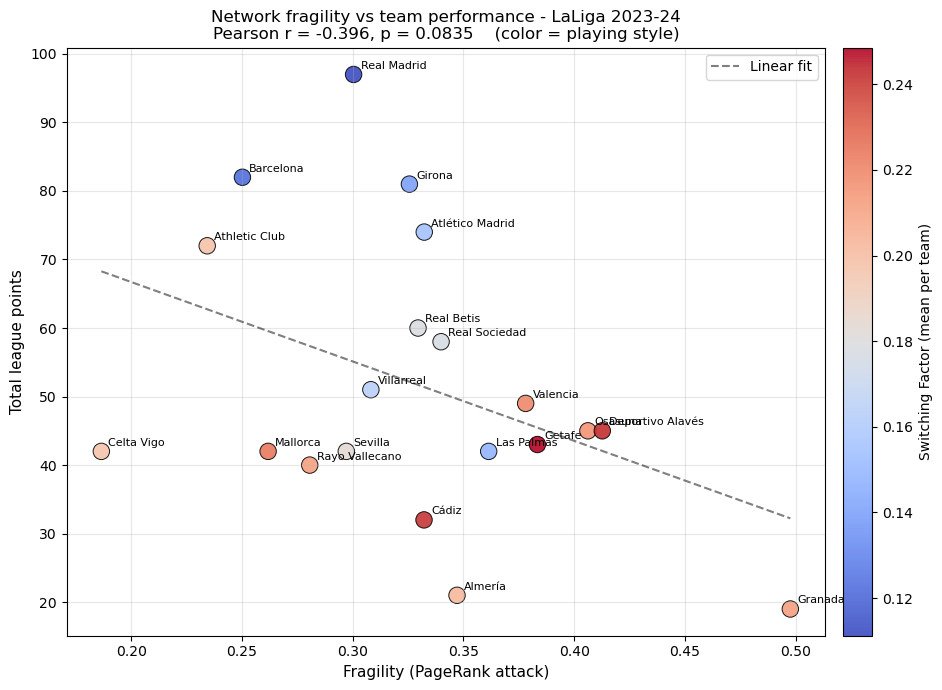

In [9]:
# Scatter: x = fragility (PageRank), y = points, COLOR = SF (continuous)
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(df['fragility_pagerank'], df['total_points'],
                c=df['sf_mean'], cmap='coolwarm',
                s=140, alpha=0.9, edgecolors='black', linewidths=0.7)

for _, row in df.iterrows():
    ax.annotate(row['team'],
                (row['fragility_pagerank'], row['total_points']),
                fontsize=8, textcoords='offset points', xytext=(5, 4))

# Linear fit
m, b = np.polyfit(df['fragility_pagerank'], df['total_points'], 1)
x_line = np.linspace(df['fragility_pagerank'].min(),
                     df['fragility_pagerank'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linestyle='--',
        alpha=0.5, linewidth=1.5, label='Linear fit')

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Switching Factor (mean per team)', fontsize=10)

ax.set_xlabel('Fragility (PageRank attack)', fontsize=11)
ax.set_ylabel('Total league points', fontsize=11)
ax.set_title(f'Network fragility vs team performance - LaLiga 2023-24\n'
             f'Pearson r = {r_pearson_pr:+.3f}, p = {p_pearson_pr:.4f}    '
             f'(color = playing style)',
             fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fragility_vs_points_pagerank.png',
            dpi=130, bbox_inches='tight')
plt.show()
plt.close()

### 4. Correlation: Betweenness fragility vs Points

In [10]:
r_pearson_bt,  p_pearson_bt  = pearsonr(df['fragility_betweenness'], df['total_points'])
r_spearman_bt, p_spearman_bt = spearmanr(df['fragility_betweenness'], df['total_points'])

print(f"Correlation (Betweenness fragility vs total points):")
print(f"  Pearson:  r = {r_pearson_bt:+.3f}, p = {p_pearson_bt:.4f}")
print(f"  Spearman: r = {r_spearman_bt:+.3f}, p = {p_spearman_bt:.4f}")

Correlation (Betweenness fragility vs total points):
  Pearson:  r = -0.252, p = 0.2834
  Spearman: r = -0.047, p = 0.8446


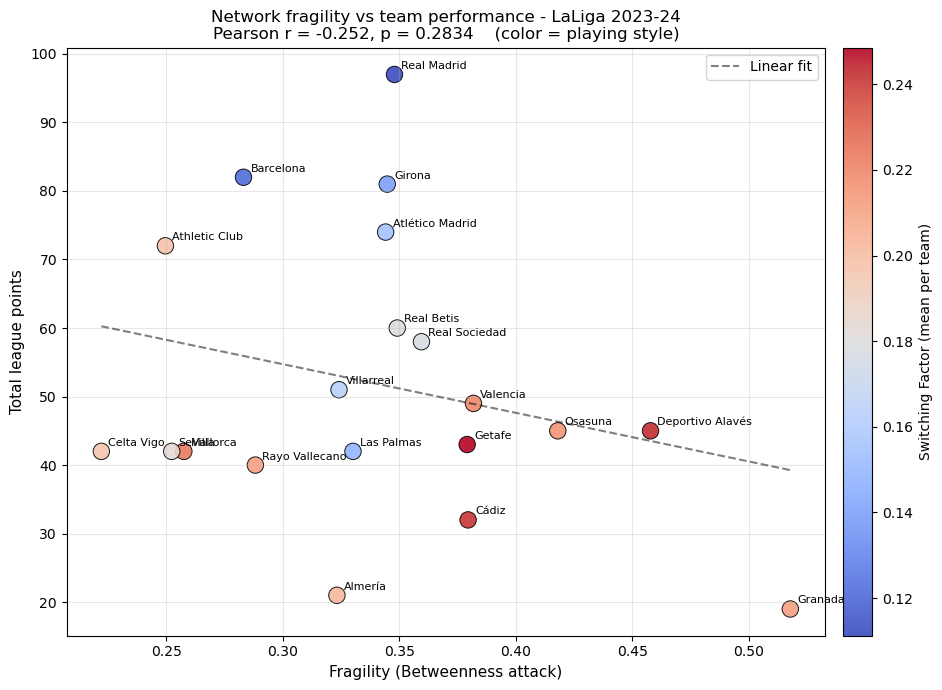

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(df['fragility_betweenness'], df['total_points'],
                c=df['sf_mean'], cmap='coolwarm',
                s=140, alpha=0.9, edgecolors='black', linewidths=0.7)

for _, row in df.iterrows():
    ax.annotate(row['team'],
                (row['fragility_betweenness'], row['total_points']),
                fontsize=8, textcoords='offset points', xytext=(5, 4))

m, b = np.polyfit(df['fragility_betweenness'], df['total_points'], 1)
x_line = np.linspace(df['fragility_betweenness'].min(),
                     df['fragility_betweenness'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linestyle='--',
        alpha=0.5, linewidth=1.5, label='Linear fit')

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Switching Factor (mean per team)', fontsize=10)

ax.set_xlabel('Fragility (Betweenness attack)', fontsize=11)
ax.set_ylabel('Total league points', fontsize=11)
ax.set_title(f'Network fragility vs team performance - LaLiga 2023-24\n'
             f'Pearson r = {r_pearson_bt:+.3f}, p = {p_pearson_bt:.4f}    '
             f'(color = playing style)',
             fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fragility_vs_points_betweenness.png',
            dpi=130, bbox_inches='tight')
plt.show()

### 5. Correlation: LCC and diameter fragility vs Points

In [12]:
for col, label in [('fragility_LCC', 'LCC'), ('fragility_diameter', 'Diameter')]:
    r, p = pearsonr(df[col], df['total_points'])
    print(f'{label:9s}-based fragility vs points:  r = {r:+.3f}, p = {p:.4f}')

LCC      -based fragility vs points:  r = -0.313, p = 0.1791
Diameter -based fragility vs points:  r = +0.282, p = 0.2277


### 6. Independence check: Style (SF) vs Fragility

In [13]:
r_pearson_sf_fr,  p_pearson_sf_fr  = pearsonr(df['sf_mean'], df['fragility_pagerank'])
r_spearman_sf_fr, p_spearman_sf_fr = spearmanr(df['sf_mean'], df['fragility_pagerank'])

print(f"Correlation (SF vs PageRank fragility):")
print(f"  Pearson:  r = {r_pearson_sf_fr:+.3f}, p = {p_pearson_sf_fr:.4f}")
print(f"  Spearman: r = {r_spearman_sf_fr:+.3f}, p = {p_spearman_sf_fr:.4f}")

Correlation (SF vs PageRank fragility):
  Pearson:  r = +0.320, p = 0.1692
  Spearman: r = +0.400, p = 0.0806


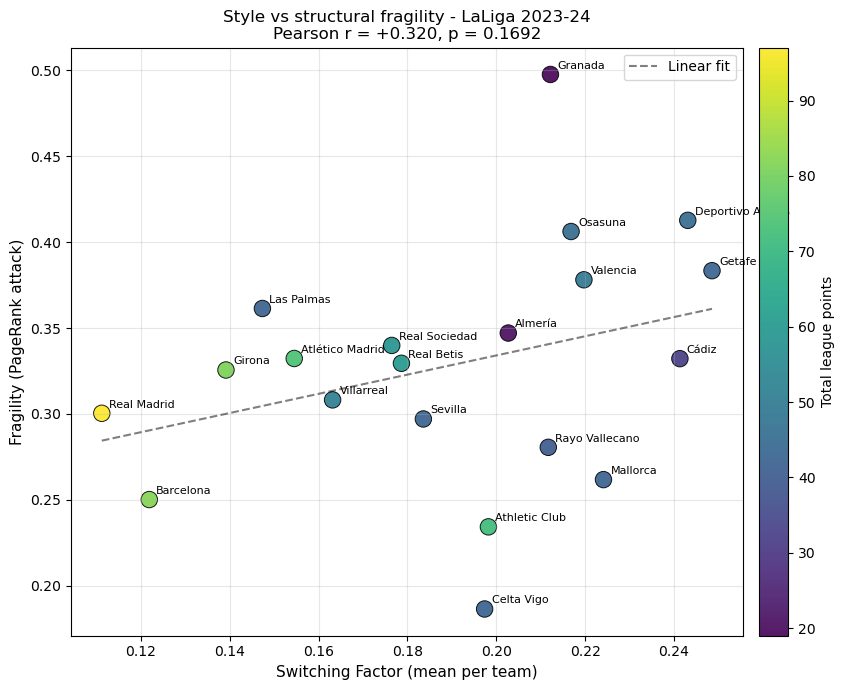

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(df['sf_mean'], df['fragility_pagerank'],
           c=df['total_points'], cmap='viridis',
           s=140, alpha=0.9, edgecolors='black', linewidths=0.7)

for _, row in df.iterrows():
    ax.annotate(row['team'],
                (row['sf_mean'], row['fragility_pagerank']),
                fontsize=8, textcoords='offset points', xytext=(5, 4))

m, b = np.polyfit(df['sf_mean'], df['fragility_pagerank'], 1)
x_line = np.linspace(df['sf_mean'].min(), df['sf_mean'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linestyle='--',
        alpha=0.5, linewidth=1.5, label='Linear fit')

sc = ax.collections[0]
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Total league points', fontsize=10)

ax.set_xlabel('Switching Factor (mean per team)', fontsize=11)
ax.set_ylabel('Fragility (PageRank attack)', fontsize=11)
ax.set_title(f'Style vs structural fragility - LaLiga 2023-24\n'
             f'Pearson r = {r_pearson_sf_fr:+.3f}, p = {p_pearson_sf_fr:.4f}',
             fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/sf_vs_fragility_pagerank.png',
            dpi=130, bbox_inches='tight')
plt.show()

### Summary

In [15]:
print("=" * 70)
print("SUMMARY - Fragility vs League Performance")
print("=" * 70)
print()
print(f"  Fragility (PageRank)    vs Points: r = {r_pearson_pr:+.3f}, p = {p_pearson_pr:.4f}")
print(f"  Fragility (Betweenness) vs Points: r = {r_pearson_bt:+.3f}, p = {p_pearson_bt:.4f}")
print(f"  Style (SF) vs Fragility (PageRank): r = {r_pearson_sf_fr:+.3f}, p = {p_pearson_sf_fr:.4f}")
print()

SUMMARY - Fragility vs League Performance

  Fragility (PageRank)    vs Points: r = -0.396, p = 0.0835
  Fragility (Betweenness) vs Points: r = -0.252, p = 0.2834
  Style (SF) vs Fragility (PageRank): r = +0.320, p = 0.1692

